Đang huấn luyện mô hình...
Đang xử lý biểu đồ...


<Figure size 1000x600 with 0 Axes>

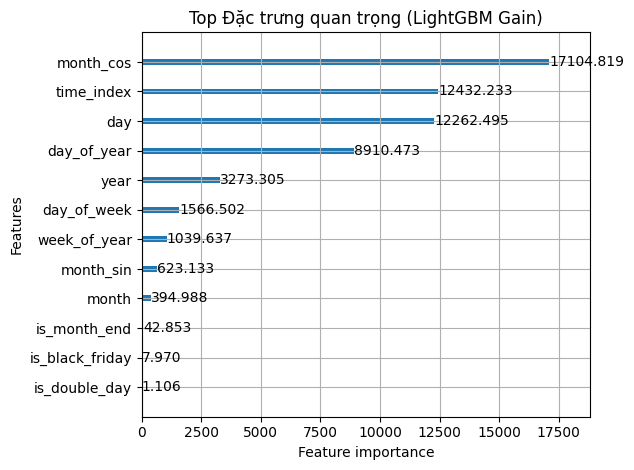

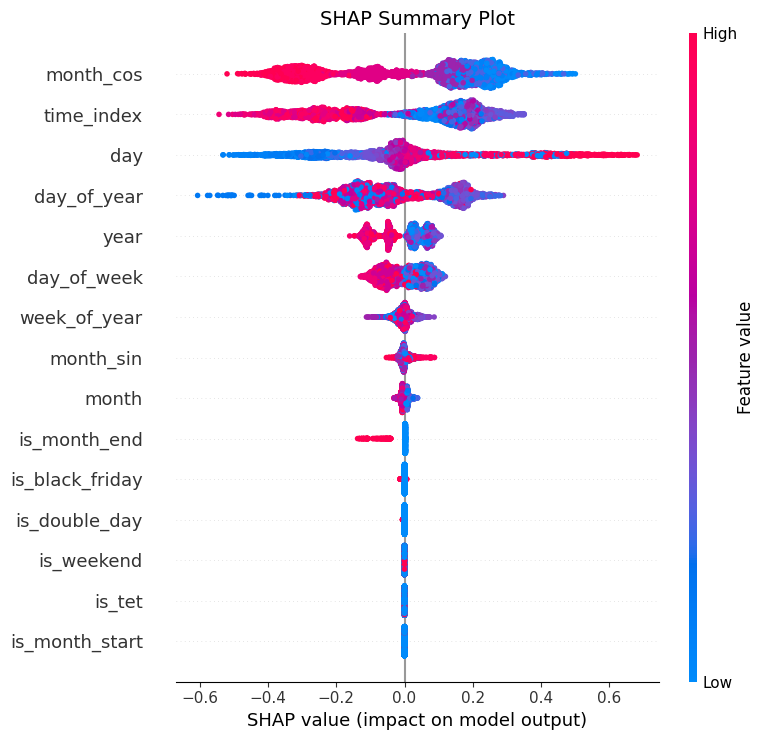

In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

# 1. NẠP VÀ XỬ LÝ DỮ LIỆU
sales_training_data = pd.read_csv('sales.csv', parse_dates=['Date'])
sales_training_data = sales_training_data.sort_values('Date').reset_index(drop=True)

q99 = sales_training_data['Revenue'].quantile(0.99)
sales_training_data['Revenue_Smoothed'] = np.where(
    sales_training_data['Revenue'] > q99,
    q99,
    sales_training_data['Revenue']
)

# 2. TẠO ĐẶC TRƯNG
def extract_features(df):
    df = df.copy()
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['day_of_year'] = df['Date'].dt.dayofyear
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_month_start'] = df['Date'].dt.is_month_start.astype(int)
    df['is_month_end'] = df['Date'].dt.is_month_end.astype(int)
    df['is_double_day'] = (df['month'] == df['day']).astype(int)
    df['is_black_friday'] = ((df['month'] == 11) & (df['day'] >= 23) & (df['day'] <= 28)).astype(int)
    df['is_tet'] = df['month'].isin([1, 2]).astype(int)
    df['time_index'] = (df['Date'] - df['Date'].min()).dt.days
    return df

training_features = extract_features(sales_training_data)
features = ['year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year',
            'month_sin', 'month_cos', 'is_weekend', 'is_month_start', 'is_month_end',
            'is_double_day', 'is_black_friday', 'is_tet', 'time_index']

X_train = training_features[features]
y_train_log = np.log1p(training_features['Revenue_Smoothed'])

# 3. HUẤN LUYỆN MÔ HÌNH
print("Đang huấn luyện mô hình...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.01, num_leaves=31,
    objective='huber', random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train_log)

# 4. VẼ BIỂU ĐỒ SHAP VÀ FEATURE IMPORTANCE
print("Đang xử lý biểu đồ...")

# Biểu đồ 1: Feature Importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain',
                    title='Top Đặc trưng quan trọng (LightGBM Gain)')
plt.tight_layout()
plt.show()

# Biểu đồ 2: SHAP Summary Plot
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_train)

plt.figure(figsize=(10, 6))
plt.title('SHAP Summary Plot', fontsize=14)
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.show()